1) write a program to detect edge of a image.

(Text(0.5, 1.0, 'Edge Image'), ([], []), ([], []))

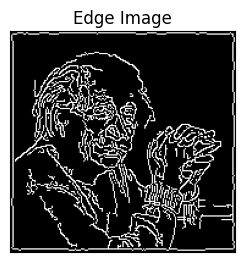

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('b.jpg',0)
edges = cv2.Canny(img,100,200)

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'),plt.xticks([]),plt.yticks([])
plt.subplot(121),plt.imshow(edges,cmap='gray')
plt.title('Edge Image'),plt.xticks([]),plt.yticks([])


2) Write a program to scale an image.

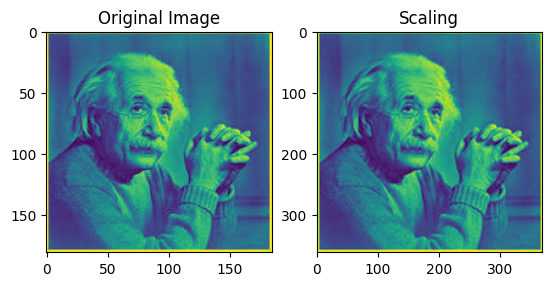

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img=cv2.imread('b.jpg',0)

#res=cv2.resize(img,None,fx=2,fy=2,interpolation=cv2.INTER_CUBIC)

height, width =img.shape[:2]
res =cv2.resize(img,(2*width,2*height),interpolation=cv2.INTER_CUBIC)

plt.subplot(121),plt.imshow(img),plt.title('Original Image')
#plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]),plt.yticks([])
plt.show()


3) Write a program showing a thresholding process on an image.

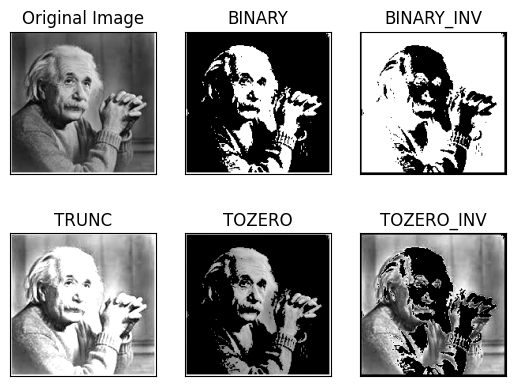

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('b.jpg',0)
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()



Intensity Transformations
# (Negative, Log, Power/Gamma, Contrast Stretching)

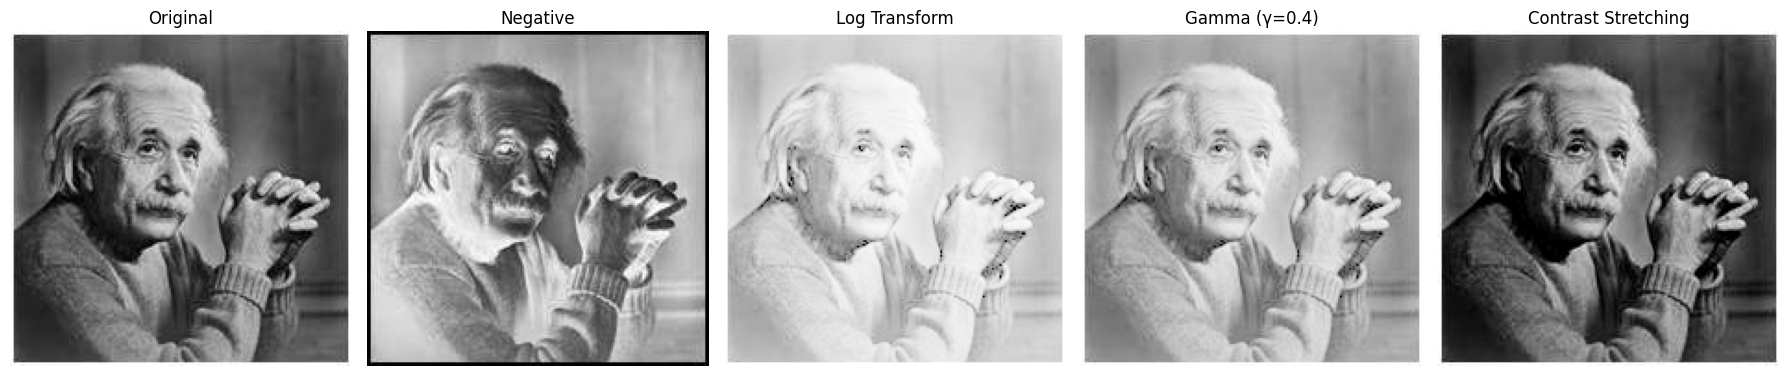

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a sample grayscale image. Use your own file if needed.
img_gray = cv2.imread('b.jpg', cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    img_gray = cv2.resize(np.linspace(0, 255, 512*512, dtype=np.uint8).reshape(512, 512), (512, 512))

negative = 255 - img_gray
log_transformed = np.uint8(255 * np.log1p(img_gray) / np.log(256))
gamma = 0.4
gamma_transformed = np.uint8(255 * ((img_gray / 255.0) ** gamma))

# Manual contrast stretching: map [p2, p98] to [0, 255]
p2, p98 = np.percentile(img_gray, (2, 98))
contrast_stretched = np.clip((img_gray - p2) * 255.0 / (p98 - p2), 0, 255).astype(np.uint8)

images = [img_gray, negative, log_transformed, gamma_transformed, contrast_stretched]
titles = ['Original', 'Negative', 'Log Transform', f'Gamma (γ={gamma})', 'Contrast Stretching']

plt.figure(figsize=(18, 4))
for i, (image, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(1, 5, i)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


Imports + Image Loader (FIXED FOR LOCAL PC)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Helper: display images
# ----------------------------
def show(images, titles, cmap_list=None, figsize=(16, 4)):
    n = len(images)
    if cmap_list is None:
        cmap_list = ['gray'] * n

    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, img, title, cmap in zip(axes, images, titles, cmap_list):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# ----------------------------
# Load image (LOCAL VERSION)
# ----------------------------

# OPTION 1: Load your own image (recommended)
# img_gray = cv2.imread("your_image.jpg", cv2.IMREAD_GRAYSCALE)

# OPTION 2: fallback test image from OpenCV (no skimage needed)
img_gray = cv2.imread(cv2.samples.findFile("b.jpg"), cv2.IMREAD_GRAYSCALE)

# If lena not available, create synthetic image
if img_gray is None:
    img_gray = np.tile(np.linspace(0, 255, 512, dtype=np.uint8), (512, 1))

img_gray = cv2.resize(img_gray, (512, 512))

print("Setup complete. Image shape:", img_gray.shape)

Setup complete. Image shape: (512, 512)


Intensity Transformations

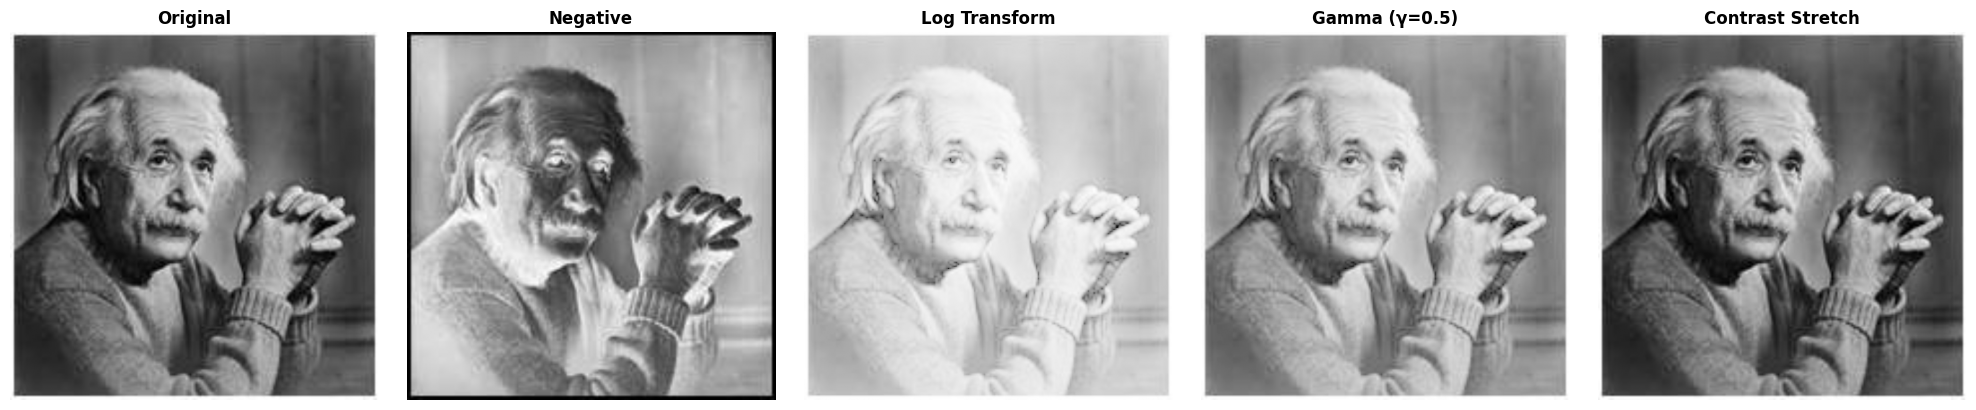

In [2]:
def intensity_transformations(img):
    img = img.astype(np.float64)
    L = 256

    negative = L - 1 - img

    c = (L - 1) / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)

    gamma = 0.5
    gamma_img = (img / 255.0) ** gamma * 255

    r_min, r_max = img.min(), img.max()
    contrast = (img - r_min) / (r_max - r_min) * 255

    show(
        [img.astype(np.uint8),
         negative.astype(np.uint8),
         log_img.astype(np.uint8),
         gamma_img.astype(np.uint8),
         contrast.astype(np.uint8)],
        ['Original', 'Negative', 'Log Transform', f'Gamma (γ={gamma})', 'Contrast Stretch'],
        figsize=(20, 4)
    )

intensity_transformations(img_gray)

Histogram Processing

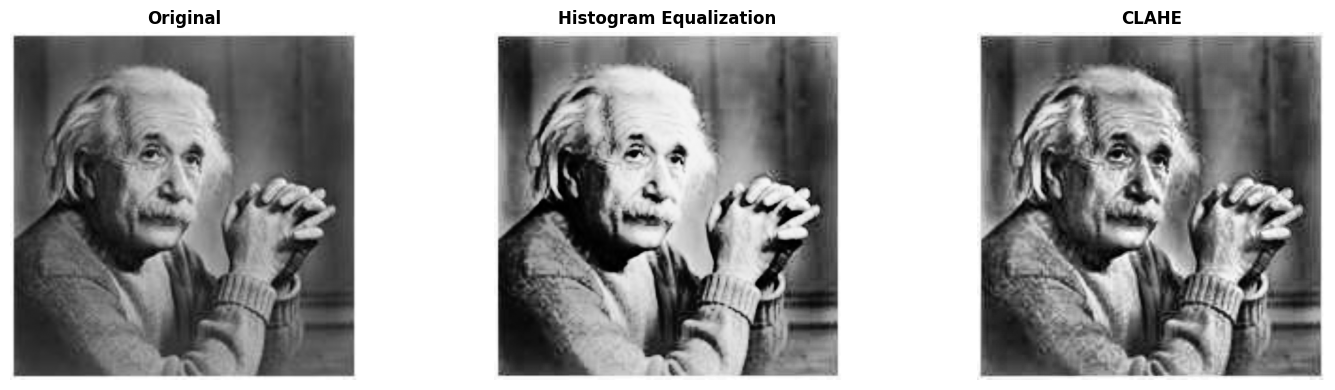

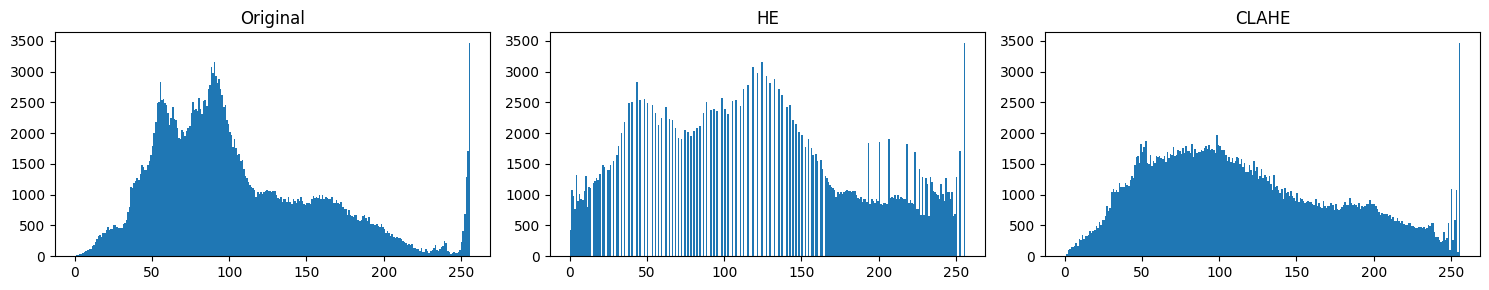

In [3]:
def histogram_processing(img):

    hist_eq = cv2.equalizeHist(img)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(img)

    show(
        [img, hist_eq, clahe_img],
        ['Original', 'Histogram Equalization', 'CLAHE'],
        figsize=(15, 4)
    )

    # Histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))

    for ax, image, title in zip(
        axes,
        [img, hist_eq, clahe_img],
        ['Original', 'HE', 'CLAHE']
    ):
        ax.hist(image.ravel(), bins=256, range=(0, 256))
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

histogram_processing(img_gray)

Smoothing Filters

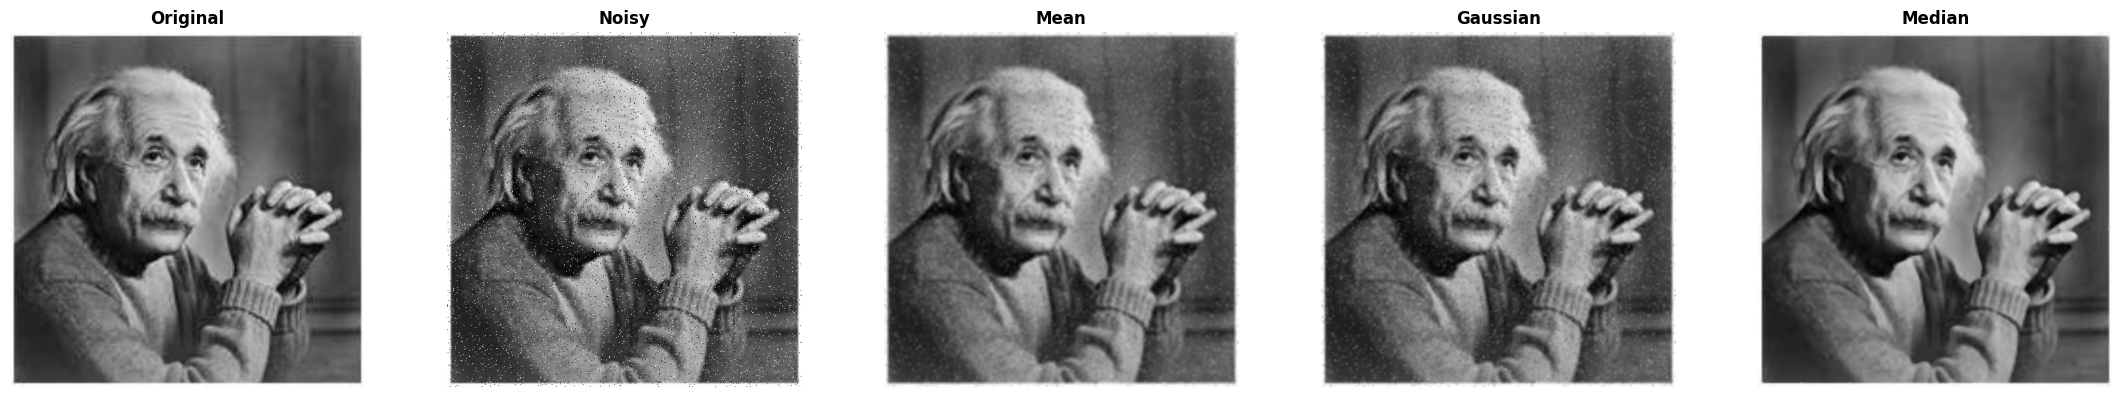

In [4]:
def smoothing_filters(img):

    noisy = img.copy()

    num_salt = int(0.02 * img.size)

    coords = [np.random.randint(0, d, num_salt) for d in img.shape]
    noisy[tuple(coords)] = 255

    coords = [np.random.randint(0, d, num_salt) for d in img.shape]
    noisy[tuple(coords)] = 0

    ksize = 5

    mean_f = cv2.blur(noisy, (ksize, ksize))
    gauss_f = cv2.GaussianBlur(noisy, (ksize, ksize), 1.5)
    median_f = cv2.medianBlur(noisy, ksize)

    show(
        [img, noisy, mean_f, gauss_f, median_f],
        ['Original', 'Noisy', 'Mean', 'Gaussian', 'Median'],
        figsize=(22, 4)
    )

smoothing_filters(img_gray)

Sharpening Filters

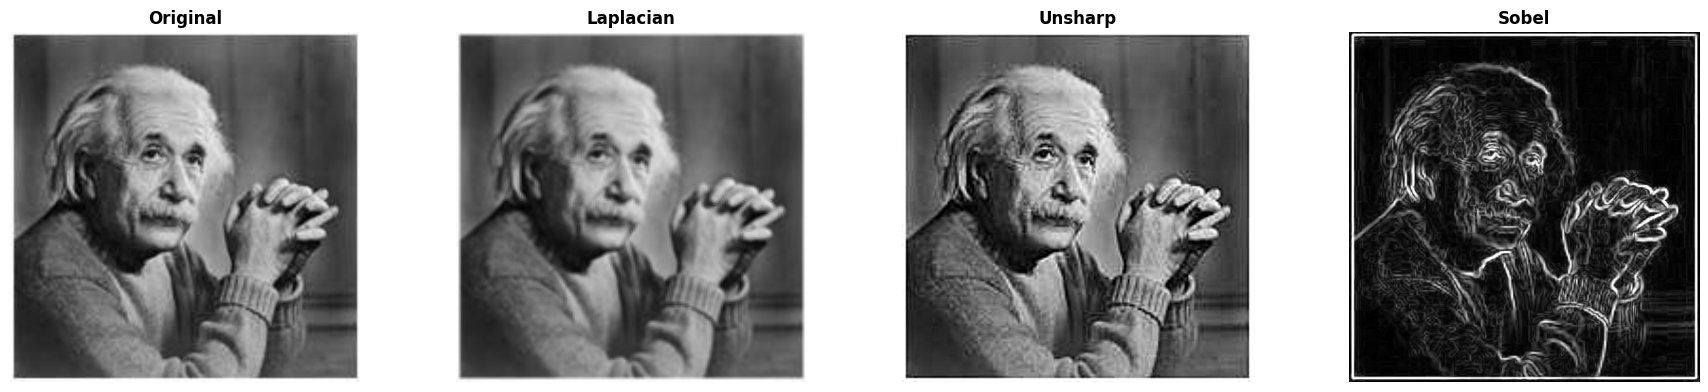

In [5]:
def sharpening_filters(img):

    img_f = img.astype(np.float64)

    laplacian_kernel = np.array([[0, -1, 0],
                                  [-1, 4, -1],
                                  [0, -1, 0]], dtype=np.float64)

    laplacian = cv2.filter2D(img_f, -1, laplacian_kernel)
    lap_sharp = np.clip(img_f - laplacian, 0, 255).astype(np.uint8)

    k = 1.5
    blurred = cv2.GaussianBlur(img, (9, 9), 2).astype(np.float64)
    unsharp = np.clip(img_f + k * (img_f - blurred), 0, 255).astype(np.uint8)

    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, 3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, 3)
    sobel_mag = np.clip(np.sqrt(sobelx**2 + sobely**2), 0, 255).astype(np.uint8)

    show(
        [img, lap_sharp, unsharp, sobel_mag],
        ['Original', 'Laplacian', 'Unsharp', 'Sobel'],
        figsize=(18, 4)
    )

sharpening_filters(img_gray)

Full Pipeline

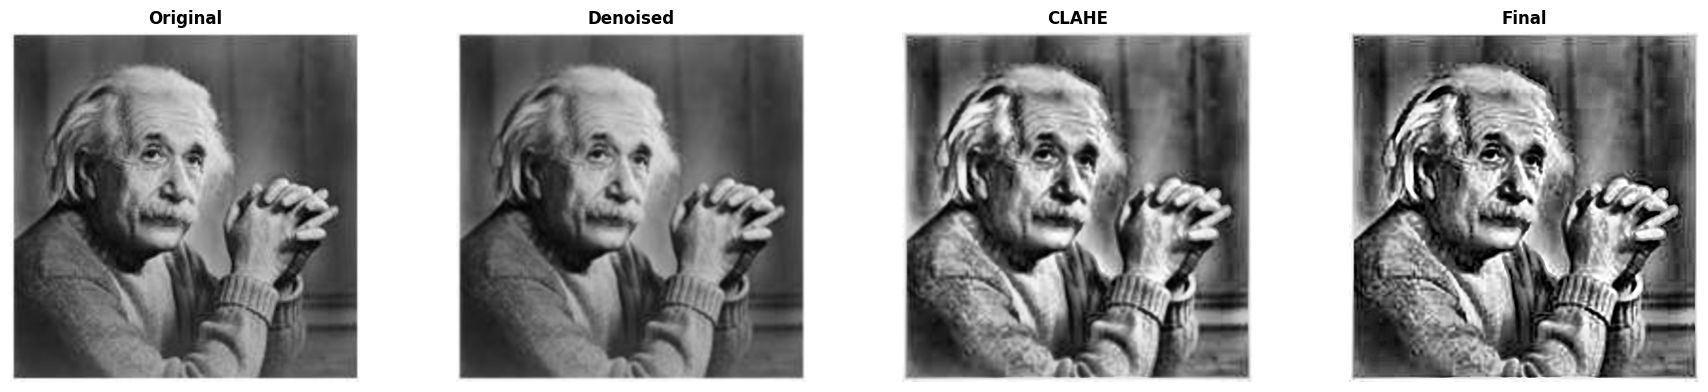

PSNR: 17.656912792739746


In [ ]:
def full_enhancement_pipeline(img):

    denoised = cv2.GaussianBlur(img, (5, 5), 1.0)

    clahe = cv2.createCLAHE(3.0, (8, 8))
    enhanced = clahe.apply(denoised)

    blurred = cv2.GaussianBlur(enhanced, (9, 9), 2).astype(np.float64)
    k = 1.2

    sharpened = np.clip(
        enhanced.astype(np.float64) +
        k * (enhanced.astype(np.float64) - blurred),
        0, 255
    ).astype(np.uint8)

    show(
        [img, denoised, enhanced, sharpened],
        ['Original', 'Denoised', 'CLAHE', 'Final'],
        figsize=(18, 4)
    )

    psnr = cv2.PSNR(img, sharpened)
    print("PSNR:", psnr)

full_enhancement_pipeline(img_gray)